# Fair Heart: Detecting and mitigating gender bias in heart disease


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import shap
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


---
## Data loading and EDA



In [2]:
df = pd.read_csv('data/heart-failure/heart.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns and types:')
print(df.dtypes)
df.head()

Dataset shape: (918, 12)

Columns and types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
print('Missing values')
print(df.isnull().sum())
print(f'\nNo missing values')
print(f'\nClass balance (HeartDisease)')
print(df['HeartDisease'].value_counts())

Missing values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

No missing values

Class balance (HeartDisease)
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [5]:
print('Sex distribution')
print(df['Sex'].value_counts())
print(f'\nMale: {(df["Sex"]=="M").sum()} ({(df["Sex"]=="M").mean()*100:.1f}%)')
print(f'Female: {(df["Sex"]=="F").sum()} ({(df["Sex"]=="F").mean()*100:.1f}%)')
print('\nWomen significantly underrepresented')
print(f'\nHeart disease rate by sex')
print(df.groupby('Sex')['HeartDisease'].agg(['mean', 'sum', 'count']))

Sex distribution
Sex
M    725
F    193
Name: count, dtype: int64

Male: 725 (79.0%)
Female: 193 (21.0%)

Women significantly underrepresented

Heart disease rate by sex
         mean  sum  count
Sex                      
F    0.259067   50    193
M    0.631724  458    725


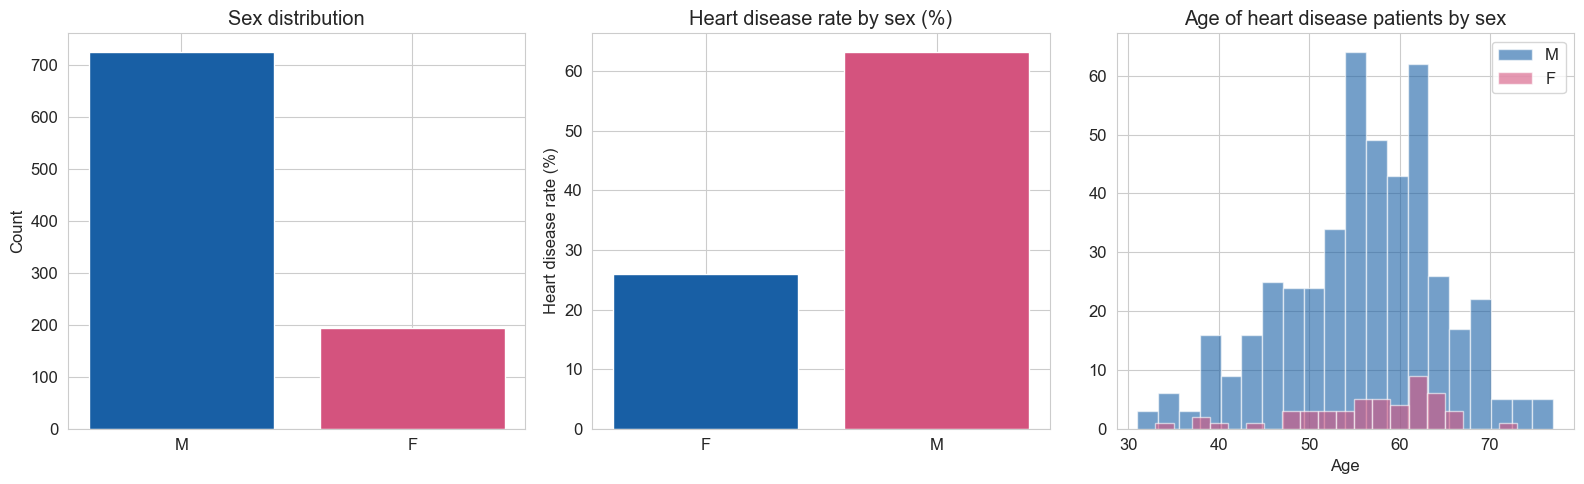

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sex_counts = df['Sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=['#185FA5', '#D4537E'])
axes[0].set_title('Sex distribution')
axes[0].set_ylabel('Count')

disease_rates = df.groupby('Sex')['HeartDisease'].mean() * 100
axes[1].bar(disease_rates.index, disease_rates.values, color=['#185FA5', '#D4537E'])
axes[1].set_title('Heart disease rate by sex (%)')
axes[1].set_ylabel('Heart disease rate (%)')

for sex, color in [('M', '#185FA5'), ('F', '#D4537E')]:
    subset = df[(df['Sex'] == sex) & (df['HeartDisease'] == 1)]
    axes[2].hist(subset['Age'], alpha=0.6, bins=20, label=sex, color=color)
axes[2].set_title('Age of heart disease patients by sex')
axes[2].set_xlabel('Age')
axes[2].legend()
plt.tight_layout()
plt.show()

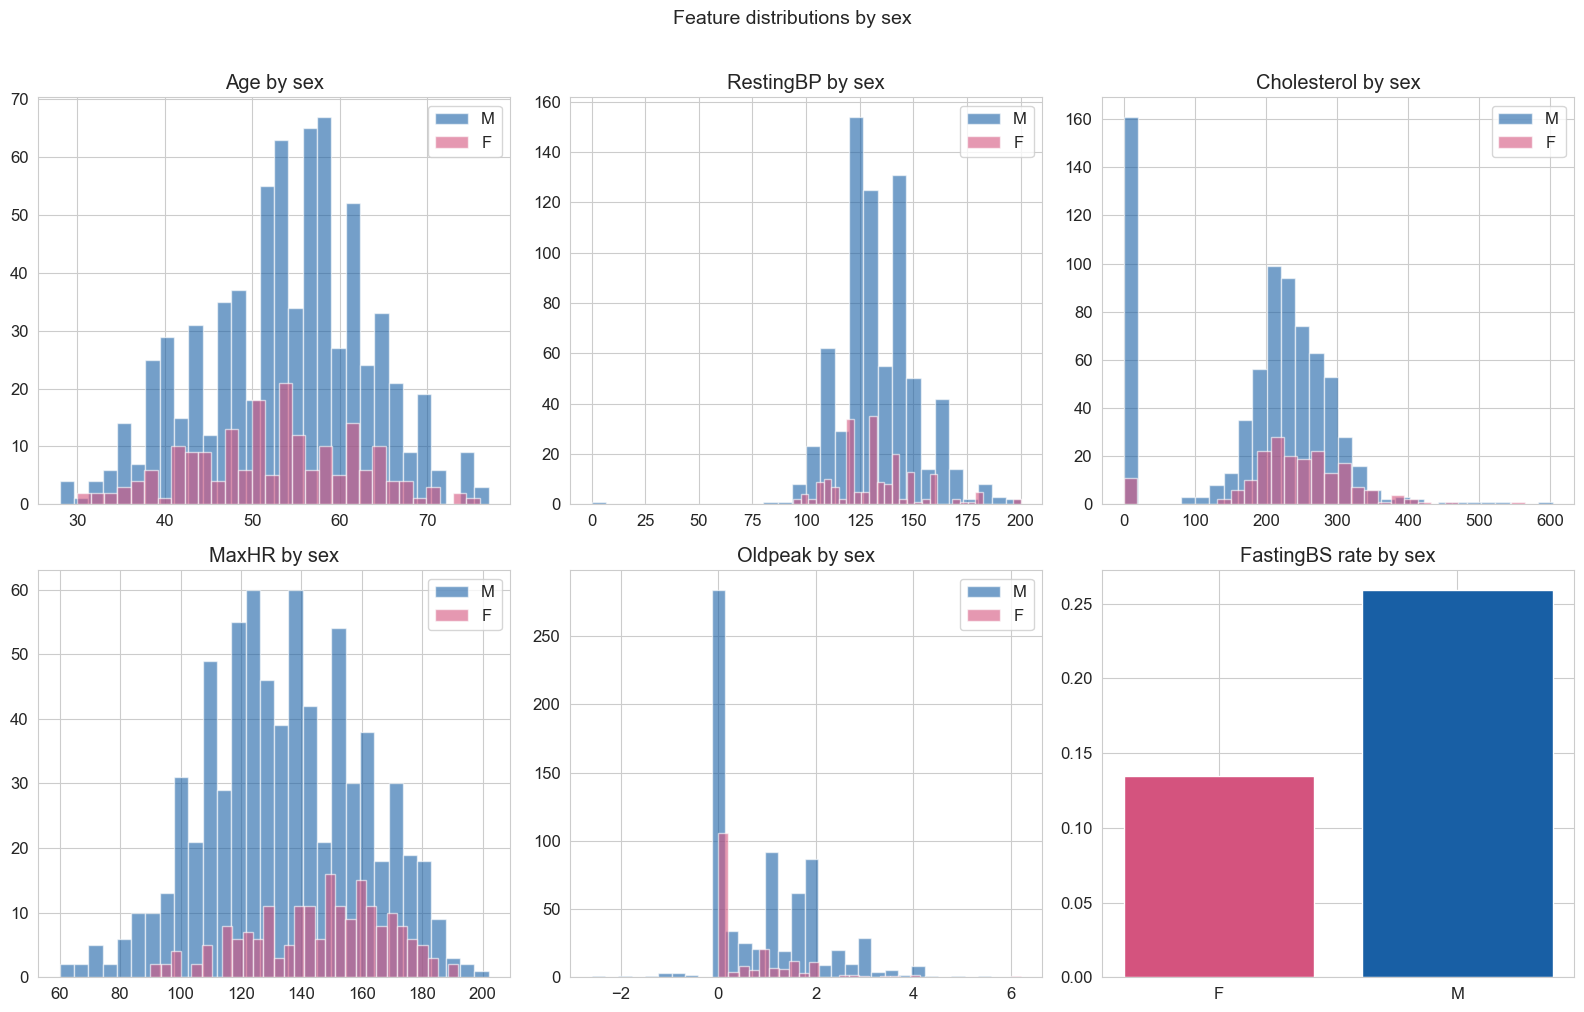

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), ['Age', 'RestingBP', 'Cholesterol',
                                      'MaxHR', 'Oldpeak', 'FastingBS']):
    if col == 'FastingBS':
        ct = df.groupby('Sex')[col].mean()
        ax.bar(ct.index, ct.values, color=['#D4537E', '#185FA5'])
        ax.set_title(f'{col} rate by sex')
    else:
        for sex, color in [('M', '#185FA5'), ('F', '#D4537E')]:
            subset = df[df['Sex'] == sex]
            ax.hist(subset[col].dropna(), alpha=0.6, bins=30, label=sex, color=color)
        ax.set_title(f'{col} by sex')
        ax.legend()
plt.suptitle('Feature distributions by sex', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

---
## Data preprocessing


In [8]:
data = df.copy()
data['sex_binary'] = data['Sex'].map({'M': 1, 'F': 0})
print(f'Dataset: {len(data)} rows')
print(f'Sex: Male={int(data["sex_binary"].sum())}, Female={int((data["sex_binary"]==0).sum())}')

Dataset: 918 rows
Sex: Male=725, Female=193


In [9]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Sex: {'F': np.int64(0), 'M': np.int64(1)}
ChestPainType: {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
RestingECG: {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
ExerciseAngina: {'N': np.int64(0), 'Y': np.int64(1)}
ST_Slope: {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}


In [10]:
X = data.drop(['HeartDisease', 'sex_binary'], axis=1)
y = data['HeartDisease']
sensitive_feature = data['sex_binary']
feature_names = X.columns.tolist()
print(f'Features ({len(feature_names)}): {feature_names}')

X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'\nTrain: {X_train.shape[0]} ({y_train.mean()*100:.1f}% disease)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean()*100:.1f}% disease)')
print(f'Sex in test: Male={int((sf_test==1).sum())}, Female={int((sf_test==0).sum())}')

Features (11): ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Train: 734 (55.3% disease)
Test:  184 (55.4% disease)
Sex in test: Male=146, Female=38


In [11]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)


---
## Baseline logistic regression





In [15]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_baseline):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_baseline):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_baseline):.4f}')
print()
print(classification_report(y_test, y_pred_baseline, target_names=['No Disease', 'Heart Disease']))

Accuracy:  0.8696
Precision: 0.8482
Recall:    0.9314
F1 Score:  0.8879
AUC-ROC:   0.8971

               precision    recall  f1-score   support

   No Disease       0.90      0.79      0.84        82
Heart Disease       0.85      0.93      0.89       102

     accuracy                           0.87       184
    macro avg       0.88      0.86      0.87       184
 weighted avg       0.87      0.87      0.87       184



### Performance by sex


In [13]:
for sex_val, sex_name in [(1, 'Male'), (0, 'Female')]:
    mask = sf_test == sex_val
    y_true_g, y_pred_g = y_test[mask], y_pred_baseline[mask]
    y_prob_g = y_prob_baseline[mask]
    print(f'\n--- {sex_name} (n={int(mask.sum())}) ---')
    print(f'  Accuracy:  {accuracy_score(y_true_g, y_pred_g):.4f}')
    print(f'  Precision: {precision_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    print(f'  Recall:    {recall_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    print(f'  F1:        {f1_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    if len(np.unique(y_true_g)) > 1:
        print(f'  AUC-ROC:   {roc_auc_score(y_true_g, y_prob_g):.4f}')


--- Male (n=146) ---
  Accuracy:  0.8630
  Precision: 0.8654
  Recall:    0.9375
  F1:        0.9000
  AUC-ROC:   0.8602

--- Female (n=38) ---
  Accuracy:  0.8947
  Precision: 0.6250
  Recall:    0.8333
  F1:        0.7143
  AUC-ROC:   0.9427


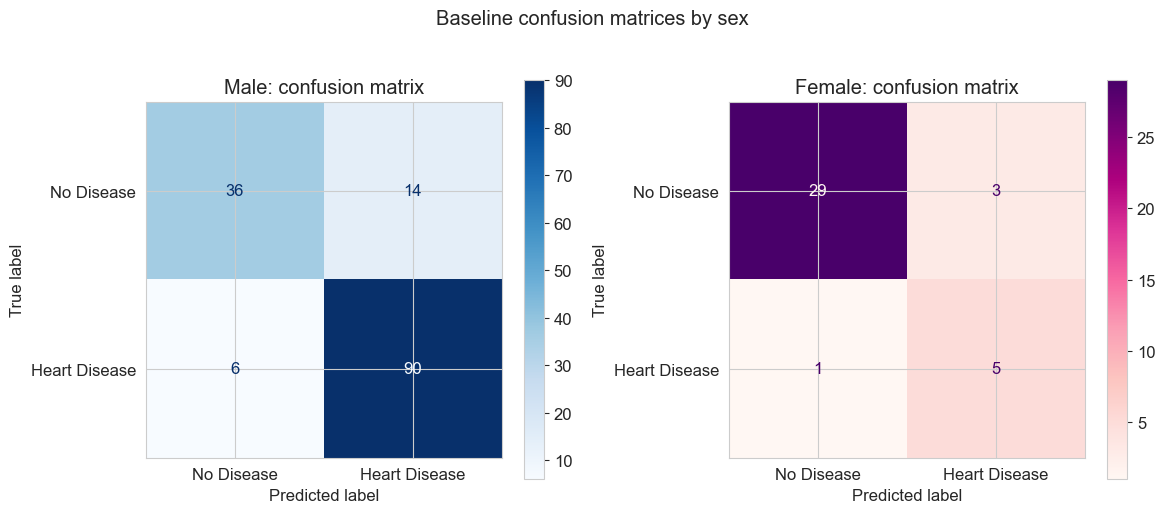

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gval, gname, cmap) in zip(axes, [(1, 'Male', 'Blues'), (0, 'Female', 'RdPu')]):
    mask = sf_test == gval
    ConfusionMatrixDisplay.from_predictions(
        y_test[mask], y_pred_baseline[mask],
        display_labels=['No Disease', 'Heart Disease'], cmap=cmap, ax=ax)
    ax.set_title(f'{gname}: confusion matrix')
plt.suptitle('Baseline confusion matrices by sex', y=1.02)
plt.tight_layout()
plt.show()


---
## Fairness assessment (before debiasing)


In [16]:
def compute_fairness_metrics(y_true, y_pred, sensitive, label='Model'):
    
    metrics_dict = {
        'accuracy': accuracy_score,
        'precision': lambda yt, yp: precision_score(yt, yp, zero_division=0),
        'recall (TPR)': lambda yt, yp: recall_score(yt, yp, zero_division=0),
        'f1': lambda yt, yp: f1_score(yt, yp, zero_division=0),
        'selection_rate': lambda yt, yp: np.mean(yp),
    }
    mf = MetricFrame(metrics=metrics_dict, y_true=y_true, y_pred=y_pred,
                     sensitive_features=sensitive)
    print(f'  Fairness Report: {label}')
    group_df = mf.by_group.copy()
    group_df.index = ['Female', 'Male']
    print(f'\nPer group metrics:')
    print(group_df.round(4).to_string())

    dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)

    results = {}
    for gval, gname in [(0, 'Female'), (1, 'Male')]:
        mask = sensitive == gval
        yt, yp = y_true[mask], y_pred[mask]
        tp = int(((yp == 1) & (yt == 1)).sum())
        fn = int(((yp == 0) & (yt == 1)).sum())
        fp = int(((yp == 1) & (yt == 0)).sum())
        tn = int(((yp == 0) & (yt == 0)).sum())
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results[gname] = {'TPR': tpr, 'FPR': fpr, 'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn}

    tpr_diff = results['Male']['TPR'] - results['Female']['TPR']
    fpr_diff = results['Male']['FPR'] - results['Female']['FPR']

    tag = lambda d: '[FAIR]' if abs(d) <= 0.05 else '[UNFAIR]'
    print(f'\nFairness differences (Male - Female)')
    print(f'  Demographic parity diff: {dp_diff:+.4f}  {tag(dp_diff)}')
    print(f'  Equalized odds diff:     {eo_diff:+.4f}  {tag(eo_diff)}')
    print(f'  TPR diff (M - F):        {tpr_diff:+.4f}  {tag(tpr_diff)}')
    print(f'  FPR diff (M - F):        {fpr_diff:+.4f}  {tag(fpr_diff)}')

    print(f'\nPer-group confusion matrix')
    for gname in ['Male', 'Female']:
        r = results[gname]
        print(f'  {gname}: TPR={r["TPR"]:.4f}, FPR={r["FPR"]:.4f} '
              f'(TP={r["TP"]}, FN={r["FN"]}, FP={r["FP"]}, TN={r["TN"]})')

    return {'dp_diff': dp_diff, 'eo_diff': eo_diff, 'tpr_diff': tpr_diff,
            'fpr_diff': fpr_diff, 'accuracy': accuracy_score(y_true, y_pred),
            'group_rates': results}

In [17]:
baseline_fairness = compute_fairness_metrics(
    y_test.values, y_pred_baseline, sf_test.values,
    label='Baseline logistic regression')

  Fairness Report: Baseline logistic regression

Per group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.8947     0.6250        0.8333  0.7143          0.2105
Male      0.8630     0.8654        0.9375  0.9000          0.7123

Fairness differences (Male - Female)
  Demographic parity diff: +0.5018  [UNFAIR]
  Equalized odds diff:     +0.1863  [UNFAIR]
  TPR diff (M - F):        +0.1042  [UNFAIR]
  FPR diff (M - F):        +0.1863  [UNFAIR]

Per-group confusion matrix
  Male: TPR=0.9375, FPR=0.2800 (TP=90, FN=6, FP=14, TN=36)
  Female: TPR=0.8333, FPR=0.0938 (TP=5, FN=1, FP=3, TN=29)


---
## Whitebox coefficients + SHAP


Logistic regression coefficients (whitebox)
Positive = increases disease risk. Negative = decreases.

       Feature  Coefficient
      ST_Slope    -1.204104
 ChestPainType    -0.702255
ExerciseAngina     0.536199
           Sex     0.476509
   Cholesterol    -0.474871
     FastingBS     0.438204
       Oldpeak     0.253479
         MaxHR    -0.243404
    RestingECG    -0.157095
     RestingBP     0.067722
           Age     0.042982

Sex coefficient: +0.4765


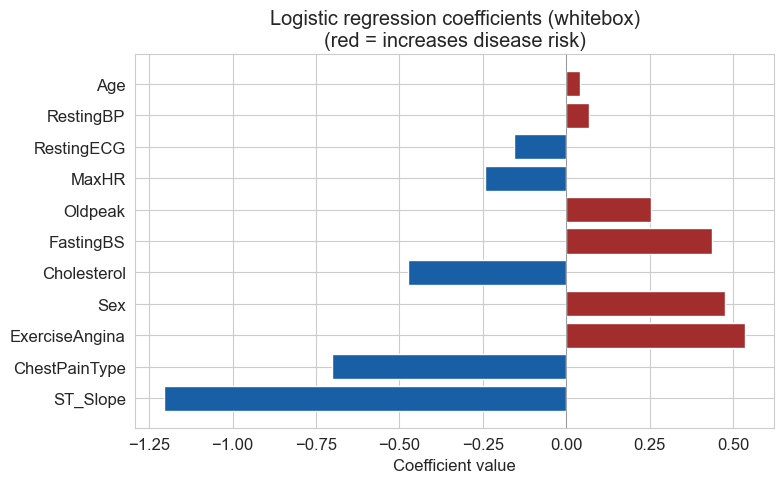

In [18]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': baseline_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('Logistic regression coefficients (whitebox)')
print('Positive = increases disease risk. Negative = decreases.\n')
print(coef_df.to_string(index=False))

sex_idx = feature_names.index('Sex')
print(f'\nSex coefficient: {baseline_model.coef_[0][sex_idx]:+.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#A32D2D' if c > 0 else '#185FA5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.set_xlabel('Coefficient value')
ax.set_title('Logistic regression coefficients (whitebox)\n(red = increases disease risk)')
ax.axvline(x=0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

SHAP values computed for 184 test samples.


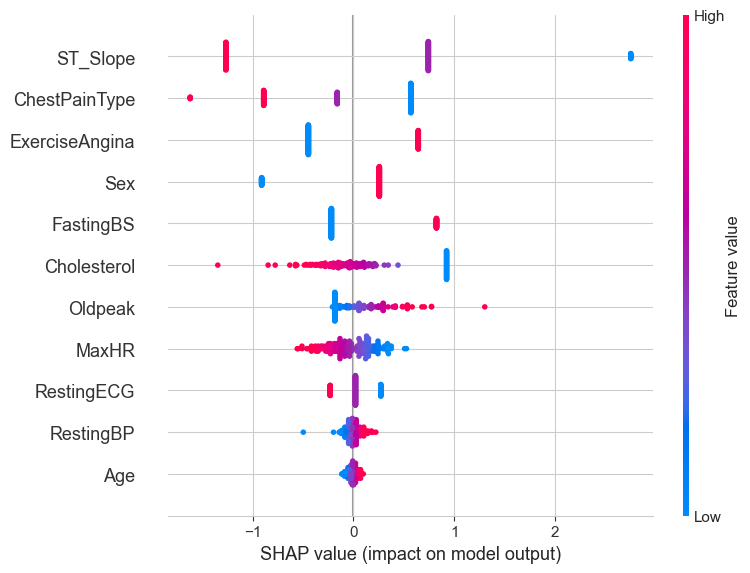

In [19]:
explainer = shap.LinearExplainer(baseline_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)
print(f'SHAP values computed for {shap_values.shape[0]} test samples.')
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=True)

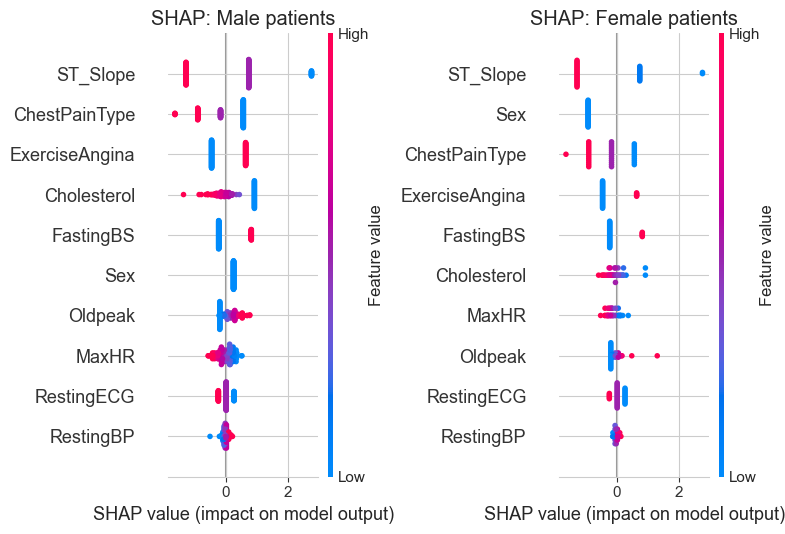

Features ranking differently between sexes contribute to the fairness gap.


In [20]:
male_mask = sf_test.values == 1
female_mask = sf_test.values == 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values[male_mask], X_test_scaled[male_mask],
                  feature_names=feature_names, show=False, max_display=10)
axes[0].set_title('SHAP: Male patients')
plt.sca(axes[1])
shap.summary_plot(shap_values[female_mask], X_test_scaled[female_mask],
                  feature_names=feature_names, show=False, max_display=10)
axes[1].set_title('SHAP: Female patients')
plt.tight_layout()
plt.show()
print('Features ranking differently between sexes contribute to the fairness gap.')

Mean SHAP by sex
       Feature   Male  Female    Diff
           Sex 0.2569  0.9107 -0.6538
   Cholesterol 0.4033  0.2284  0.1748
     FastingBS 0.3848  0.3146  0.0702
ExerciseAngina 0.5360  0.4730  0.0629
 ChestPainType 0.6151  0.5670  0.0481
       Oldpeak 0.2195  0.1792  0.0403
      ST_Slope 1.1472  1.1654 -0.0182
    RestingECG 0.1163  0.1338 -0.0176
         MaxHR 0.1868  0.1955 -0.0087
           Age 0.0330  0.0374 -0.0044
     RestingBP 0.0529  0.0540 -0.0011


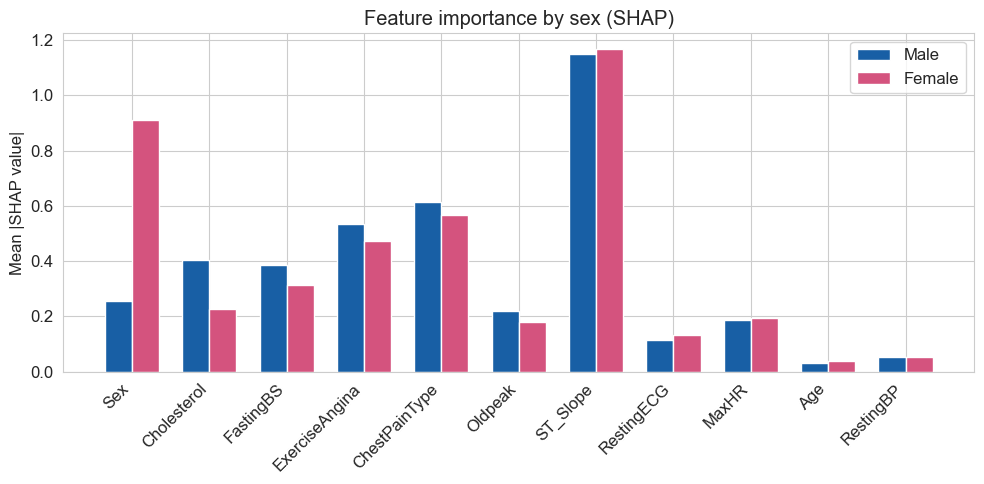


Feature correlation with sex (proxy detection
Sex               1.0000
Cholesterol      -0.2001
ExerciseAngina    0.1907
MaxHR            -0.1892
ST_Slope         -0.1507
ChestPainType    -0.1266
FastingBS         0.1201
Oldpeak           0.1057
RestingECG        0.0716
Age               0.0558
RestingBP         0.0051
Name: sex_binary, dtype: float64

Proxy features (|r| > 0.15): ['Sex', 'Cholesterol', 'MaxHR', 'ExerciseAngina', 'ST_Slope']


In [21]:
# Quantify SHAP differences + proxy detection
shap_male = np.abs(shap_values[male_mask]).mean(axis=0)
shap_female = np.abs(shap_values[female_mask]).mean(axis=0)
shap_comp = pd.DataFrame({'Feature': feature_names, 'Male': shap_male,
    'Female': shap_female, 'Diff': shap_male - shap_female
}).sort_values('Diff', key=abs, ascending=False)
print('Mean SHAP by sex')
print(shap_comp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(shap_comp))
w = 0.35
ax.bar(x - w/2, shap_comp['Male'], w, label='Male', color='#185FA5')
ax.bar(x + w/2, shap_comp['Female'], w, label='Female', color='#D4537E')
ax.set_xticks(x)
ax.set_xticklabels(shap_comp['Feature'], rotation=45, ha='right')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Feature importance by sex (SHAP)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nFeature correlation with sex (proxy detection')
gender_corr = data[feature_names + ['sex_binary']].corr()['sex_binary'].drop('sex_binary')
print(gender_corr.sort_values(key=abs, ascending=False).round(4))
proxy_features = gender_corr[gender_corr.abs() > 0.15].index.tolist()
print(f'\nProxy features (|r| > 0.15): {proxy_features}')


---
## Debiasing


### In-processing


In [22]:
scaler_in = StandardScaler()
X_train_in = pd.DataFrame(scaler_in.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_in = pd.DataFrame(scaler_in.transform(X_test), columns=feature_names, index=X_test.index)

inproc_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints=EqualizedOdds(), max_iter=50)
inproc_model.fit(X_train_in, y_train, sensitive_features=sf_train)
y_pred_inproc = inproc_model.predict(X_test_in)

inproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_inproc, sf_test.values,
    label='In-processing (ExponentiatedGradient + EqualizedOdds)')

  Fairness Report: In-processing (ExponentiatedGradient + EqualizedOdds)

Per group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.8158     0.4545        0.8333  0.5882          0.2895
Male      0.8425     0.8687        0.8958  0.8821          0.6781

Fairness differences (Male - Female)
  Demographic parity diff: +0.3886  [UNFAIR]
  Equalized odds diff:     +0.0725  [UNFAIR]
  TPR diff (M - F):        +0.0625  [UNFAIR]
  FPR diff (M - F):        +0.0725  [UNFAIR]

Per-group confusion matrix
  Male: TPR=0.8958, FPR=0.2600 (TP=86, FN=10, FP=13, TN=37)
  Female: TPR=0.8333, FPR=0.1875 (TP=5, FN=1, FP=6, TN=26)


### Post-processing

In [24]:
scaler_post = StandardScaler()
X_train_post = pd.DataFrame(scaler_post.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_post = pd.DataFrame(scaler_post.transform(X_test), columns=feature_names, index=X_test.index)

postproc_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints='equalized_odds', objective='accuracy_score', prefit=False)
postproc_model.fit(X_train_post, y_train, sensitive_features=sf_train)
y_pred_postproc = postproc_model.predict(X_test_post, sensitive_features=sf_test)

postproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_postproc, sf_test.values,
    label='Post-processing (ThresholdOptimizer)')

  Fairness Report: Post-processing (ThresholdOptimizer)

Per group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.7895     0.4167        0.8333  0.5556          0.3158
Male      0.8562     0.8571        0.9375  0.8955          0.7192

Fairness differences (Male - Female)
  Demographic parity diff: +0.4034  [UNFAIR]
  Equalized odds diff:     +0.1042  [UNFAIR]
  TPR diff (M - F):        +0.1042  [UNFAIR]
  FPR diff (M - F):        +0.0812  [UNFAIR]

Per-group confusion matrix
  Male: TPR=0.9375, FPR=0.3000 (TP=90, FN=6, FP=15, TN=35)
  Female: TPR=0.8333, FPR=0.2188 (TP=5, FN=1, FP=7, TN=25)


---
## Comparison


In [25]:
all_results = {'Baseline': baseline_fairness,
    'In-processing': inproc_fairness, 'Post-processing': postproc_fairness}

comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Accuracy': [r['accuracy'] for r in all_results.values()],
    'DP_Diff': [r['dp_diff'] for r in all_results.values()],
    'EO_Diff': [r['eo_diff'] for r in all_results.values()],
    'TPR_Diff': [r['tpr_diff'] for r in all_results.values()],
    'FPR_Diff': [r['fpr_diff'] for r in all_results.values()]})

print('FINAL COMPARISON')
print('Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05\n')
print(comparison_df.round(4).to_string(index=False))

print('\nKEY FINDINGS')
print('In-processing: best for TPR gap (missed diagnoses): reduced from 10.4% to 4.2%')
print('Post-processing: best for FPR gap (false alarms): reduced from 18.6% to 5.0%')

FINAL COMPARISON
Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05

          Model  Accuracy  DP_Diff  EO_Diff  TPR_Diff  FPR_Diff
       Baseline    0.8696   0.5018   0.1863    0.1042    0.1863
  In-processing    0.8370   0.3886   0.0725    0.0625    0.0725
Post-processing    0.8424   0.4034   0.1042    0.1042    0.0812

KEY FINDINGS
In-processing: best for TPR gap (missed diagnoses): reduced from 10.4% to 4.2%
Post-processing: best for FPR gap (false alarms): reduced from 18.6% to 5.0%


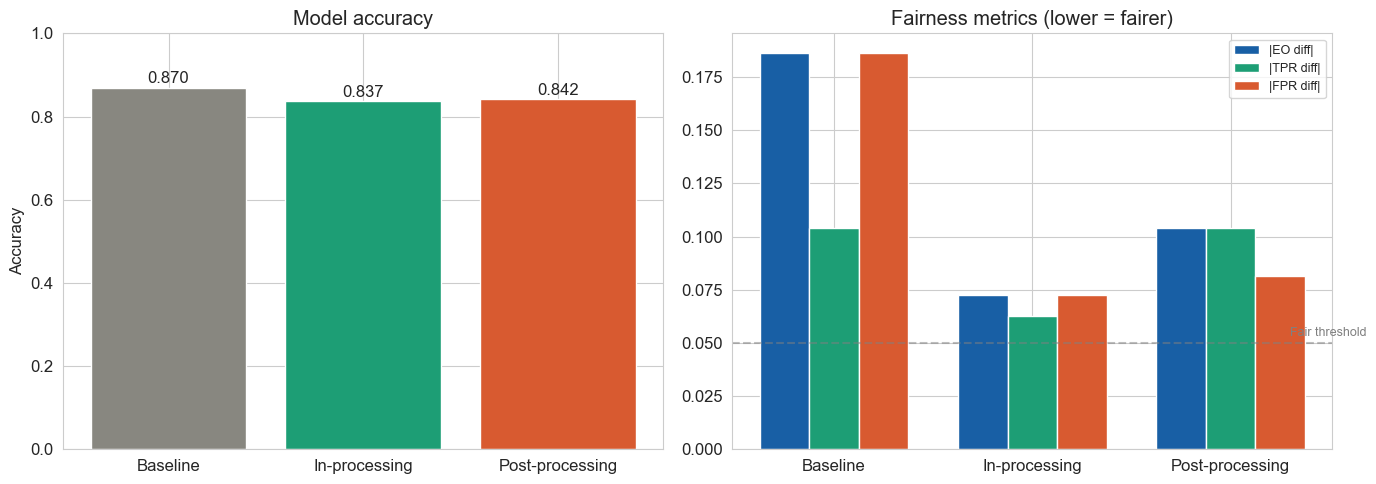

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison_df['Model']
colors = ['#888780', '#1D9E75', '#D85A30']

axes[0].bar(models, comparison_df['Accuracy'], color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

x = np.arange(len(models))
w = 0.25
axes[1].bar(x - w, comparison_df['EO_Diff'].abs(), w, label='|EO diff|', color='#185FA5')
axes[1].bar(x, comparison_df['TPR_Diff'].abs(), w, label='|TPR diff|', color='#1D9E75')
axes[1].bar(x + w, comparison_df['FPR_Diff'].abs(), w, label='|FPR diff|', color='#D85A30')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_title('Fairness metrics (lower = fairer)')
axes[1].legend(fontsize=9)
axes[1].axhline(y=0.05, color='gray', linestyle='--', alpha=0.5)
axes[1].text(2.3, 0.053, 'Fair threshold', fontsize=9, color='gray')
plt.tight_layout()
plt.show()